In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "Parquet data/"
file_name = "03.06_7" 

df = pd.read_parquet(f"{file_path}{file_name}.parquet")

In [16]:
side_tolerance = 20

# Mark observations close to any image boundary.
df["sides"] = (
    (df["x"] < side_tolerance)
    | (df["x"] > 512 - side_tolerance)
    | (df["y"] < side_tolerance)
    | (df["y"] > 640 - side_tolerance)
)

first_rows = df.loc[
    df.groupby("label", sort=False)["time"].idxmin(),
    ["label", "time", "sides"]
]

last_rows = df.loc[
    df.groupby("label", sort=False)["time"].idxmax(),
    ["label", "time", "sides"]
]

start_time = df["time"].min()
end_time = df["time"].max()
times = np.sort(df["time"].unique())

initial_count = (first_rows["time"] == start_time).sum()

entries = (
    first_rows.loc[
        first_rows["sides"] & (first_rows["time"] > start_time)
    ]
    .groupby("time")
    .size()
)

exits = (
    last_rows.loc[
        last_rows["sides"] & (last_rows["time"] < end_time)
    ]
    .groupby("time")
    .size()
    .mul(-1)
)

entry_exit_history = pd.DataFrame(index=times)
entry_exit_history["entries"] = entries
entry_exit_history["exits"] = exits
entry_exit_history = entry_exit_history.fillna(0).astype(int)

entry_exit_history["particle_count"] = (
    initial_count
    + (entry_exit_history["entries"] + entry_exit_history["exits"]).cumsum()
)

entry_exit_history.insert(0, "time", times)

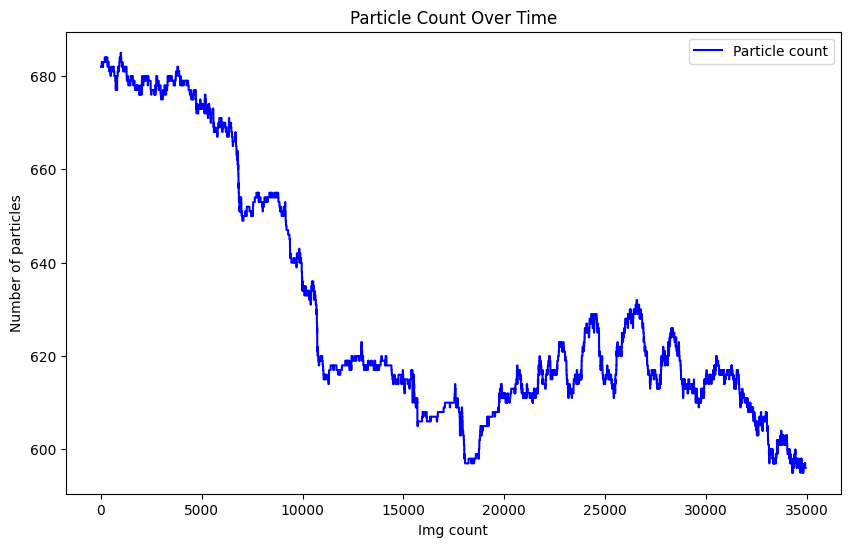

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.step(
    # entry_exit_history["time"],
    np.linspace(1, len(entry_exit_history), len(entry_exit_history)),
    entry_exit_history["particle_count"],
    where="post",
    label="Particle count",
    color="blue",
)
ax.set_xlabel("Img count")
ax.set_ylabel("Number of particles")
ax.set_title("Particle Count Over Time")
ax.legend()
plt.show()

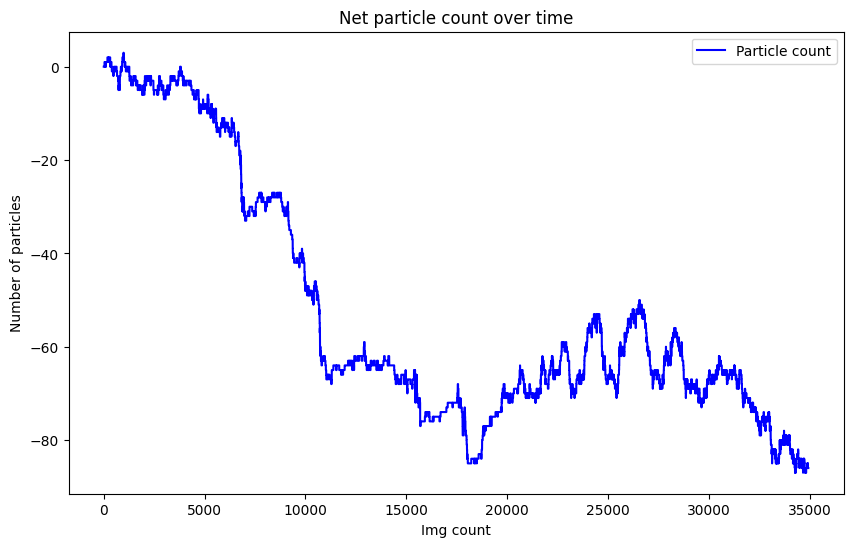

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.step(
    # entry_exit_history["time"],
    np.linspace(1, len(entry_exit_history), len(entry_exit_history)),
    entry_exit_history["particle_count"]-initial_count,
    where="post",
    label="Particle count",
    color="blue",
)
ax.set_xlabel("Img count")
ax.set_ylabel("Number of particles")
ax.set_title("Net particle count over time")
ax.legend()
plt.show()

In [26]:
# Subdivision in subregions for local coordinate analysis.
subregion_sizes = {
    1: (512, 640),
    2: (256, 320),
    4: (128, 160),
    8: (64, 80),
    16: (32, 40),
    32: (16, 20),
    64: (8, 10),
}

# Select the number of divisions along each axis.
n = 4
subregion_width, subregion_height = subregion_sizes[n]

column_index = np.floor(df["x"] / subregion_width).astype(int).clip(0, n - 1)
row_index = np.floor(df["y"] / subregion_height).astype(int).clip(0, n - 1)

df["subregion"] = row_index * n + column_index + 1

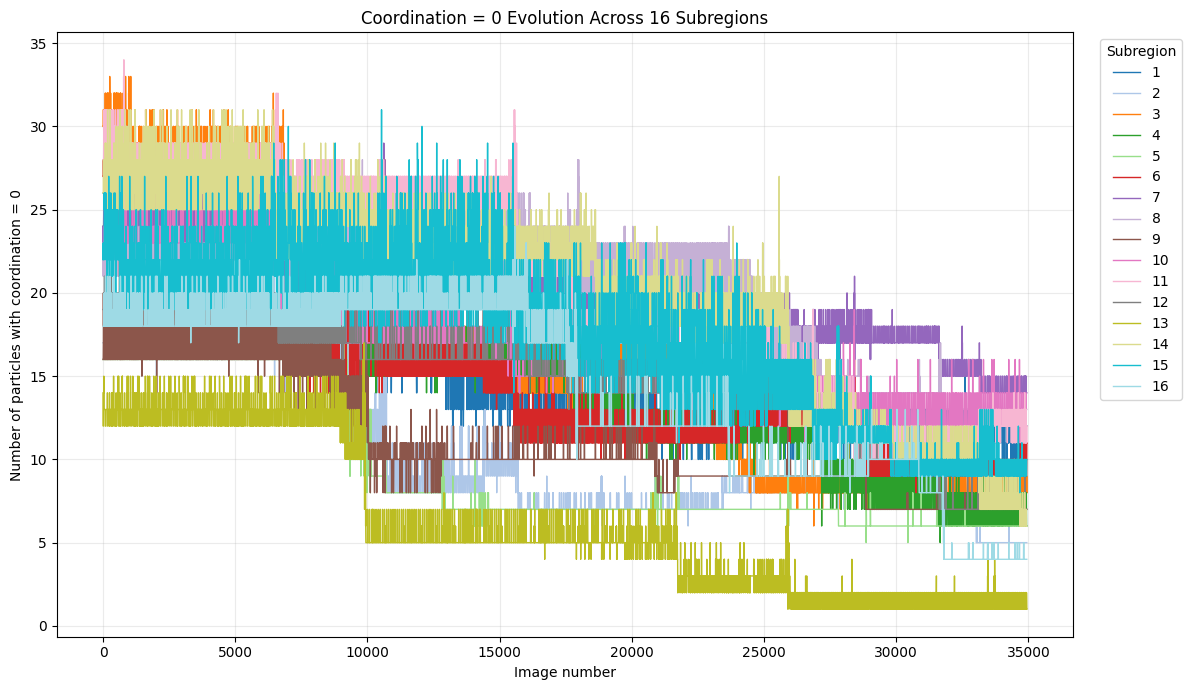

Zone patterns:\n
[1. 2. 3. 4.]
[5. 6. 7. 8.]
[ 9. 10. 11. 12.]
[13. 14. 15. 16.]


In [ ]:
# Coordination-number evolution in each subregion.
coord_num_selected = 0

coordination_counts = (
    df.loc[df["coordination"] == coord_num_selected]
    .groupby(["frame", "subregion"])["label"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=range(1, n**2 + 1), fill_value=0)
    .sort_index()
)

fig, ax = plt.subplots(figsize=(12, 7))
coordination_counts.plot(ax=ax, linewidth=1, colormap="tab20")
ax.set_xlabel("Image number")
ax.set_ylabel(f"Number of particles with coordination = {coord_num_selected}")
ax.set_title(
    f"Coordination = {coord_num_selected} Evolution Across {n**2} Subregions"
)
ax.legend(title="Subregion", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("Zone patterns:")
k = 1
for subregion in range(1, n+1):
    print(np.linspace(k, k + n -1, n))
    k += n

In [37]:
# Export coordination counts in the MATLAB-compatible format.
coordination_export = (
    coordination_counts
    .rename_axis("x")
    .reset_index()
    .melt(
        id_vars="x",
        var_name="subregion",
        value_name="y",
    )
)

coordination_export["series"] = 0
coordination_export["curve"] = coordination_export["subregion"] - 1
coordination_export["point_index"] = (
    coordination_export.groupby("subregion", sort=False).cumcount()
)
coordination_export["x_label"] = "Frames"
coordination_export["y_label"] = "Counts"

coordination_export = coordination_export[
    [
        "series",
        "curve",
        "point_index",
        "x",
        "y",
        "x_label",
        "y_label",
        "subregion",
    ]
]

output_file = (
    f"coordination_num_counts_{file_name}_{coord_num_selected}.csv"
)
coordination_export.to_csv(output_file, index=False)
print(f"Exported {len(coordination_export):,} rows to {output_file}")

Exported 559,024 rows to coordination_num_counts_03.06_7_0.csv
